# Exploring Chemical Space
On the modified ESOL dataset, some clustering techniques to explore the physicochemical diversity should be explored. Include dimensionality reduction before and visualise!

Import data

In [29]:
import pandas as pd
import numpy as np

# Load your modified ESOL dataset
df = pd.read_csv("esol_modified.csv")

# Remove non-numeric columns (keep descriptors only)
X = df.select_dtypes(include=[np.number]).copy()

# Optional: drop target column if present (e.g., logS)
if "logS" in X.columns:
    X = X.drop(columns=["logS"])

print("Shape after numeric selection:", X.shape)

Shape after numeric selection: (1128, 12)


In [30]:
df.isna().sum()

SMILES              0
LogS                0
MolWt               0
LogP                0
EState_VSA5         0
TPSA                0
NumHAcc             0
NumAromaticRings    0
HeavyAtomCount      0
RingCount           0
qed                 0
NumHDonors          0
NOCount             0
dtype: int64

In [31]:
df.duplicated().sum()

np.int64(0)

Remove low-variance features

MD: unsupervised learning is super sensitive to highly correlated and low variance features, as the distort the learning (oder so)

In [32]:
from sklearn.feature_selection import VarianceThreshold

var_filter = VarianceThreshold(threshold=0.01) # unsupervised variance threshold / alogrithm
X_var = var_filter.fit_transform(X)

X = pd.DataFrame(X_var, columns=X.columns[var_filter.get_support()])
print("After variance filter:", X.shape)

After variance filter: (1128, 12)


Remove Highly Correlated Features (>0.9)

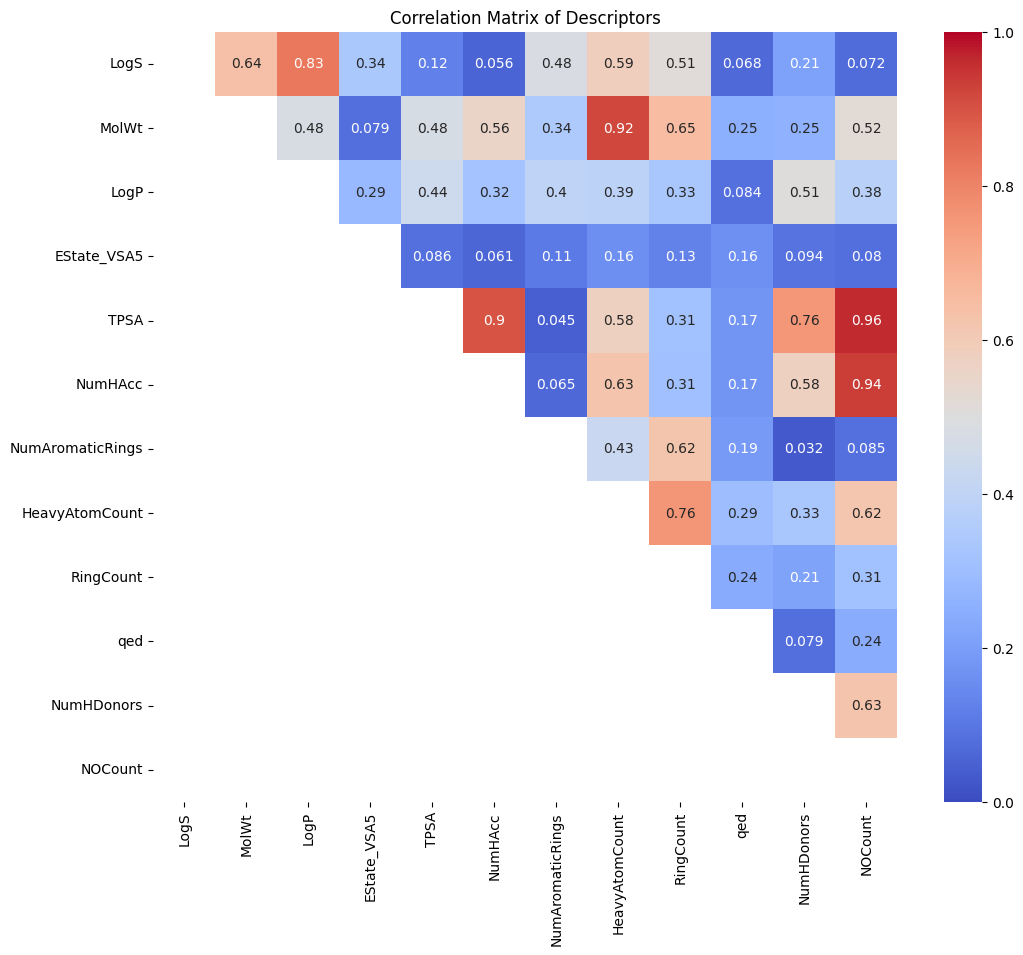

After correlation filtering: (1128, 10)
Remaining descriptors: ['LogS', 'MolWt', 'LogP', 'EState_VSA5', 'TPSA', 'NumHAcc', 'NumAromaticRings', 'RingCount', 'qed', 'NumHDonors']


In [33]:
corr_matrix = X.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# MD: visualize the correlation matrix
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 10))
sns.heatmap(upper, annot=True, cmap="coolwarm", vmin=0, vmax=1)
plt.title("Correlation Matrix of Descriptors")
plt.show()

to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]
X = X.drop(columns=to_drop)

print("After correlation filtering:", X.shape)
print("Remaining descriptors:", X.columns.tolist())

Scale the data

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

PCA (for clustering space)

In [35]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95, random_state=42) # 95% variance retained, instead of defining a fixed number of components
X_pca = pca.fit_transform(X_scaled)

print("Original dimensions:", X_scaled.shape[1])
print("PCA dimensions:", X_pca.shape[1])

Original dimensions: 10
PCA dimensions: 7


Visualisation: t-SNE

In [36]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)

Visualisation: UMAP

In [37]:
import umap

umap_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42
)

X_umap = umap_model.fit_transform(X_scaled)

/Users/mircodill/DSA104/venv3.9/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


KMeans Clustering on PCA Space

In [38]:
# Find optimal k using silhouette score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

range_k = range(2, 9)
sil_scores = []

for k in range_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_pca)
    sil_scores.append(silhouette_score(X_pca, labels))

best_k = range_k[np.argmax(sil_scores)]
print("Best k:", best_k)

Best k: 4


In [39]:
# fit final KMeans
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
kmeans_labels = kmeans.fit_predict(X_pca)

df["KMeans_cluster"] = kmeans_labels

DBSCAN Clustering on PCA space

In [40]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.6, min_samples=5)
db_labels = dbscan.fit_predict(X_pca)

df["DBSCAN_cluster"] = db_labels

print("Number of DBSCAN clusters:",
      len(set(db_labels)) - (1 if -1 in db_labels else 0))
print("Noise points:", list(db_labels).count(-1))

Number of DBSCAN clusters: 16
Noise points: 633


Evaluation metrics

In [41]:
from sklearn.metrics import davies_bouldin_score

print("KMeans silhouette:",
      silhouette_score(X_pca, kmeans_labels))

print("KMeans davies_bouldin_score:",
      davies_bouldin_score(X_pca, kmeans_labels))

if len(set(db_labels)) > 1:
    print("DBSCAN silhouette:",
          silhouette_score(X_pca, db_labels))

if len(set(db_labels)) > 1:
    print("DBSCAN davies_bouldin_score:",
          davies_bouldin_score(X_pca, db_labels))

KMeans silhouette: 0.2920585014470934
KMeans davies_bouldin_score: 1.3300417634149366
DBSCAN silhouette: -0.1558593593046106
DBSCAN davies_bouldin_score: 1.4342137504183885


Visualisation of clusters - project KMeans clustering on PCA, tSNE, UMAP

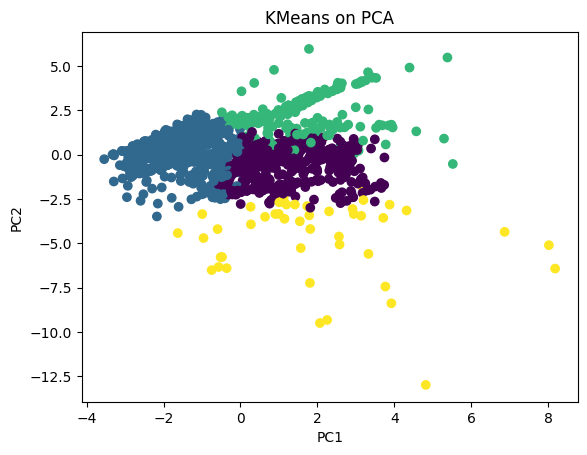

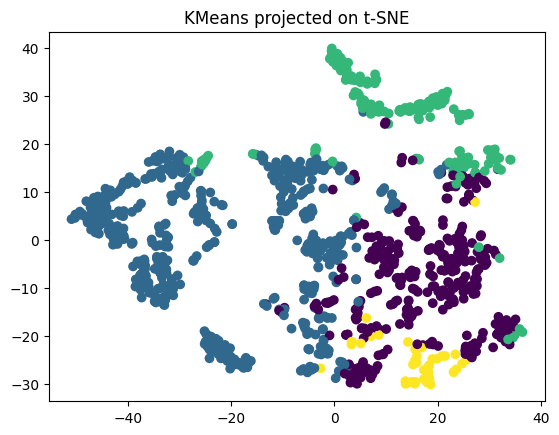

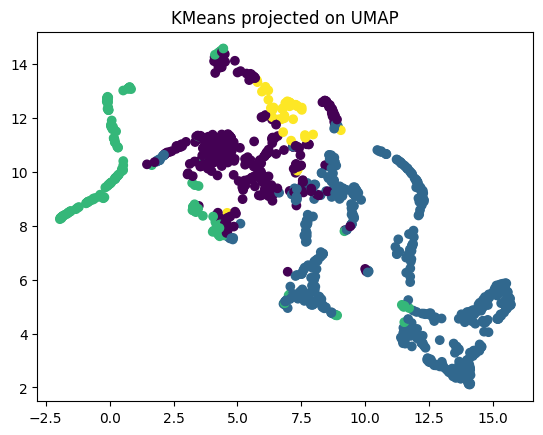

In [42]:
import matplotlib.pyplot as plt

# PCA 2D plot
plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels)
plt.title("KMeans on PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


# t-SNE plot
plt.figure()
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=kmeans_labels)
plt.title("KMeans projected on t-SNE")
plt.show()


# UMAP plot
plt.figure()
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=kmeans_labels)
plt.title("KMeans projected on UMAP")
plt.show()

Visualisation of clusters - project DBSCAN clustering on PCA, tSNE, UMAP

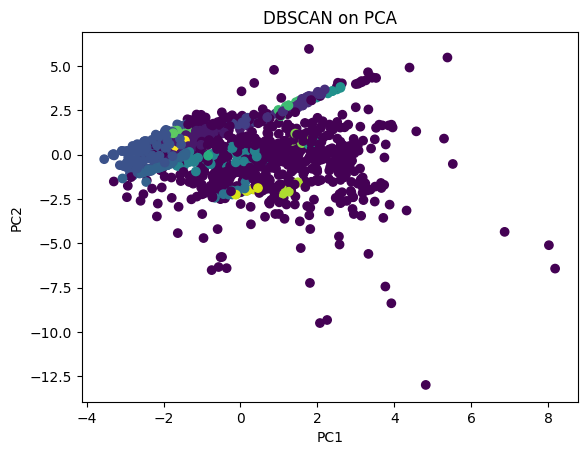

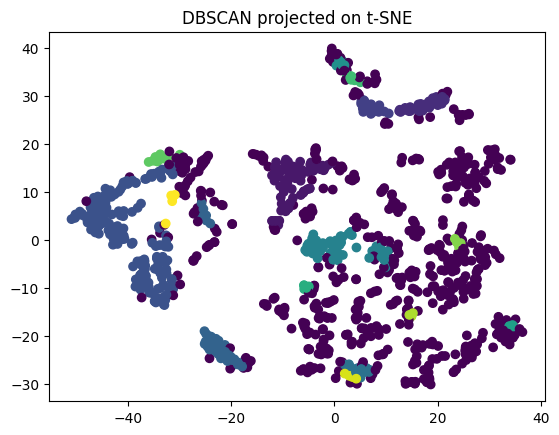

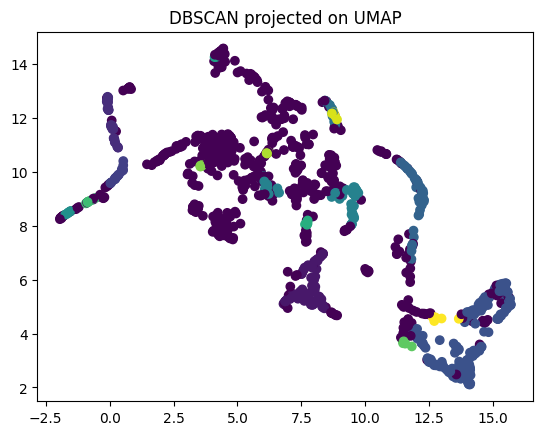

In [43]:
# PCA 2D plot
plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=db_labels)
plt.title("DBSCAN on PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


# t-SNE plot
plt.figure()
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=db_labels)
plt.title("DBSCAN projected on t-SNE")
plt.show()


# UMAP plot
plt.figure()
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=db_labels)
plt.title("DBSCAN projected on UMAP")
plt.show()

Access Molecules from clusters via cluster labels:

In [44]:
df["KMeans_cluster"] = kmeans_labels
df["DBSCAN_cluster"] = db_labels

In [45]:
df

,SMILES,LogS,MolWt,LogP,EState_VSA5,TPSA,NumHAcc,NumAromaticRings,HeavyAtomCount,RingCount,qed,NumHDonors,NOCount,KMeans_cluster,DBSCAN_cluster
0,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,-0.770,457.432,-3.10802,0.000000,202.32,12.0,1.0,32.0,3.0,0.217518,7.0,12.0,3,-1
1,Cc1occc1C(=O)Nc2ccccc2,-3.300,201.225,2.84032,6.263163,42.24,2.0,2.0,15.0,2.0,0.811283,1.0,3.0,0,-1
2,CC(C)=CCCC(C)=CC(=O),-2.060,152.237,2.87800,5.573105,17.07,1.0,0.0,11.0,0.0,0.343706,0.0,1.0,1,-1
3,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,-7.870,278.354,6.29940,43.089794,0.00,0.0,5.0,22.0,5.0,0.291526,0.0,0.0,2,-1
4,c1ccsc1,-1.330,84.143,1.74810,0.000000,0.00,1.0,1.0,5.0,1.0,0.448927,0.0,0.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1123,FC(F)(F)C(Cl)Br,-1.710,197.381,2.50850,0.000000,0.00,0.0,0.0,7.0,0.0,0.523506,0.0,0.0,1,3
1124,CNC(=O)ON=C(SC)C(=O)N(C)C,0.106,219.266,0.10710,11.947582,71.00,5.0,0.0,14.0,0.0,0.293876,1.0,6.0,1,-1
1125,CCSCCSP(=S)(OC)OC,-3.091,246.359,2.99000,0.000000,18.46,5.0,0.0,12.0,0.0,0.506070,0.0,2.0,1,-1
1126,CCC(C)C,-3.180,72.151,2.05240,6.420822,0.00,0.0,0.0,5.0,0.0,0.444441,0.0,0.0,1,3


In [46]:
# Get all molecules from KMeans cluster 0
cluster_0 = df[df["KMeans_cluster"] == 0]

print(cluster_0[["SMILES"]].head())
print("Cluster size:", len(cluster_0))

                                              SMILES
1                             Cc1occc1C(=O)Nc2ccccc2
7                   CC12CCC3C(CCc4cc(O)ccc34)C2CCC1O
9   COc5cc4OCC3Oc2c1CC(Oc1ccc2C(=O)C3c4cc5OC)C(C)=C 
13                        CCC1(C(=O)NCNC1=O)c2ccccc2
18                  CCOP(=S)(OCC)Oc1cc(C)nc(n1)C(C)C
Cluster size: 349


In [60]:
# Get the DBSCAN Noise Molecules (outliers = intersting molecules?)
noise = df[df["DBSCAN_cluster"] == -1]

display(df["DBSCAN_cluster"].value_counts())
print("Number of datapoints:", len(df))
print("Number of outliers:", len(noise))
print(noise[["SMILES"]].head())

DBSCAN_cluster
-1     633
 3     176
 0      74
 6      61
 4      49
 1      35
 2      22
 5      18
 11     12
 10      8
 7       7
 9       6
 8       6
 12      6
 14      5
 13      5
 15      5
Name: count, dtype: int64

Number of datapoints: 1128
Number of outliers: 633
                                              SMILES
0  OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...
1                             Cc1occc1C(=O)Nc2ccccc2
2                               CC(C)=CCCC(C)=CC(=O)
3                 c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43
5                                     c2ccc1scnc1c2 


Identify representative molecules for KMeans clusters via centroids:

In [63]:
from scipy.spatial.distance import cdist

print(df["KMeans_cluster"].value_counts())
cluster_id = 2

cluster_indices = np.where(kmeans_labels == cluster_id)[0]
cluster_points = X_pca[cluster_indices]

centroid = kmeans.cluster_centers_[cluster_id].reshape(1, -1)

distances = cdist(cluster_points, centroid)
closest_index = cluster_indices[np.argmin(distances)]

representative_molecule = df.iloc[closest_index]

print("Representative SMILES:", representative_molecule["SMILES"])

KMeans_cluster
1    549
0    349
2    185
3     45
Name: count, dtype: int64
Representative SMILES: c2(Cl)c(Cl)c(Cl)c1nccnc1c2(Cl) 


Visualise Molecules from certain clusters via RDKIT

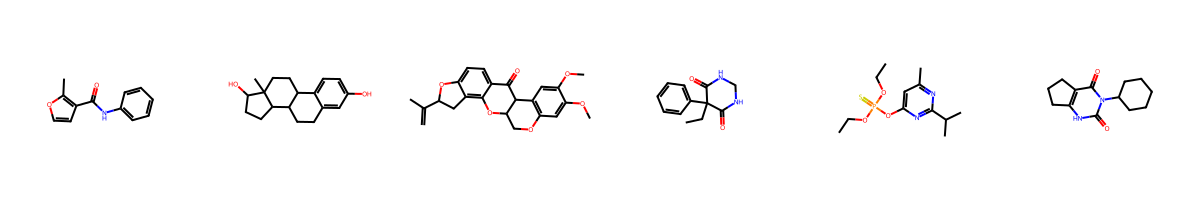

In [66]:
from rdkit import Chem
from rdkit.Chem import Draw

cluster_0 = df[df["KMeans_cluster"] == 0].head(6)

mols = [Chem.MolFromSmiles(sm) for sm in cluster_0["SMILES"]]

Draw.MolsToGridImage(mols, molsPerRow=6)

Compare clusters accross methods (where is the noise located? are clusters consistent?)

In [67]:
pd.crosstab(df["KMeans_cluster"], df["DBSCAN_cluster"])

DBSCAN_cluster,-1,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
KMeans_cluster,,,,,,,,,,,,,,,,,
0,296,0,0,0,0,0,16,15,0,6,0,0,0,6,5,5,0
1,179,73,0,1,176,49,2,46,0,0,6,0,12,0,0,0,5
2,113,1,35,21,0,0,0,0,7,0,0,8,0,0,0,0,0
3,45,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Cluster Exploration: Compare for each cluster

1) Report cluster size
2) Report centroid representative molecule
3) Show 4–6 example structures
4) Report key descriptor means
5) Compare to global dataset mean

In [51]:
summary = df.groupby("KMeans_cluster").agg({
    "LogS": "mean",
    "MolWt": "mean",
    "LogP": "mean",
    "NumHDonors": "mean",
    "NumHAcc": "mean"
})

print(summary)

                    LogS       MolWt      LogP  NumHDonors   NumHAcc
KMeans_cluster                                                      
0              -3.404212  266.168582  2.429673    1.031519  3.627507
1              -1.850235  126.912026  1.842115    0.402550  1.058288
2              -6.217616  289.616632  5.148831    0.129730  1.113514
3              -1.920156  308.764578 -1.133522    4.133333  7.311111


In [52]:
summary2 = df.groupby("KMeans_cluster")["LogS"].mean()
print(summary2)

KMeans_cluster
0   -3.404212
1   -1.850235
2   -6.217616
3   -1.920156
Name: LogS, dtype: float64
